In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

plt.style.use("ggplot")

In [6]:
from prophet import Prophet
print("Prophet Installed Successfully")

Prophet Installed Successfully


In [7]:
df = pd.read_csv(r"C:\Users\91895\OneDrive\Desktop\NeuralRetail\data\processed\cleaned_retail.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [8]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='object')

In [9]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate']
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805549 entries, 0 to 805548
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  int64         
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[ns]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  object        
 8   Revenue      805549 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 55.3+ MB


In [10]:
daily_sales = (df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum().reset_index())
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])
daily_sales.head()

,ds,y
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


In [11]:
print("Rows:", daily_sales.shape[0])

daily_sales.describe()

Rows: 604


,ds,y
count,604,604.000000
mean,2010-12-09 10:17:29.006622464,29376.538374
min,2009-12-01 00:00:00,3457.110000
25%,2010-06-09 18:00:00,18830.260000
50%,2010-12-04 00:00:00,25703.780000
75%,2011-06-15 06:00:00,35558.427500
max,2011-12-09 00:00:00,184367.280000
std,NaN,17051.748185


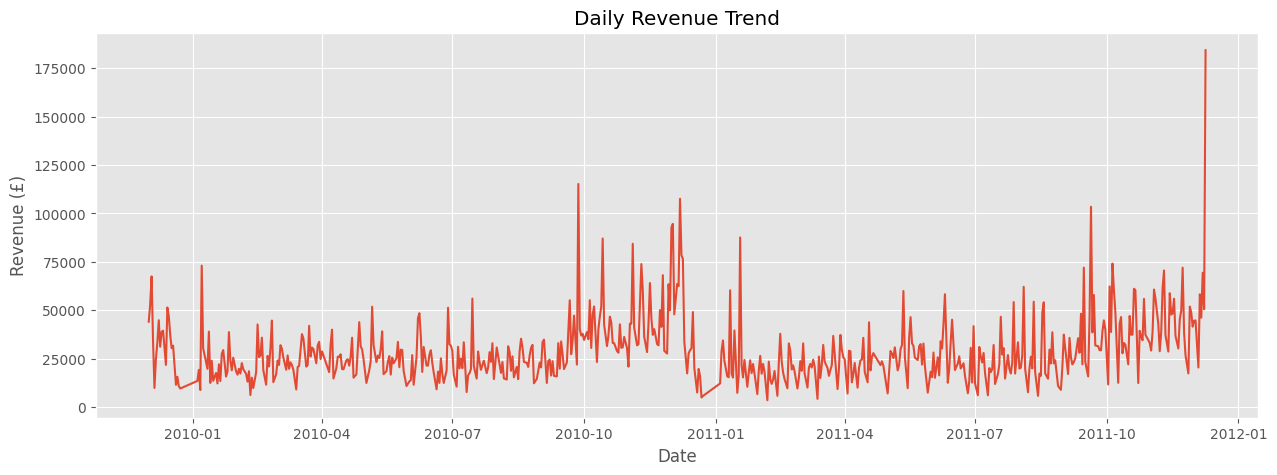

In [12]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales['ds'],
    daily_sales['y']
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue (£)")

plt.show()

In [13]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(daily_sales)

19:01:38 - cmdstanpy - INFO - Chain [1] start processing
19:01:40 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
future = model.make_future_dataframe(
    periods=90
)

future.tail()

,ds
689,2012-03-04
690,2012-03-05
691,2012-03-06
692,2012-03-07
693,2012-03-08


In [15]:
forecast = model.predict(future)

forecast[
    ['ds',
     'yhat',
     'yhat_lower',
     'yhat_upper']
].tail()

,ds,yhat,yhat_lower,yhat_upper
689,2012-03-04,12452.493625,-1918.575037,27734.752917
690,2012-03-05,23563.383838,7418.730758,39611.595426
691,2012-03-06,25966.516102,9935.153738,42177.182592
692,2012-03-07,23038.501429,7209.136062,39066.228594
693,2012-03-08,29966.174684,12971.420580,46747.899192


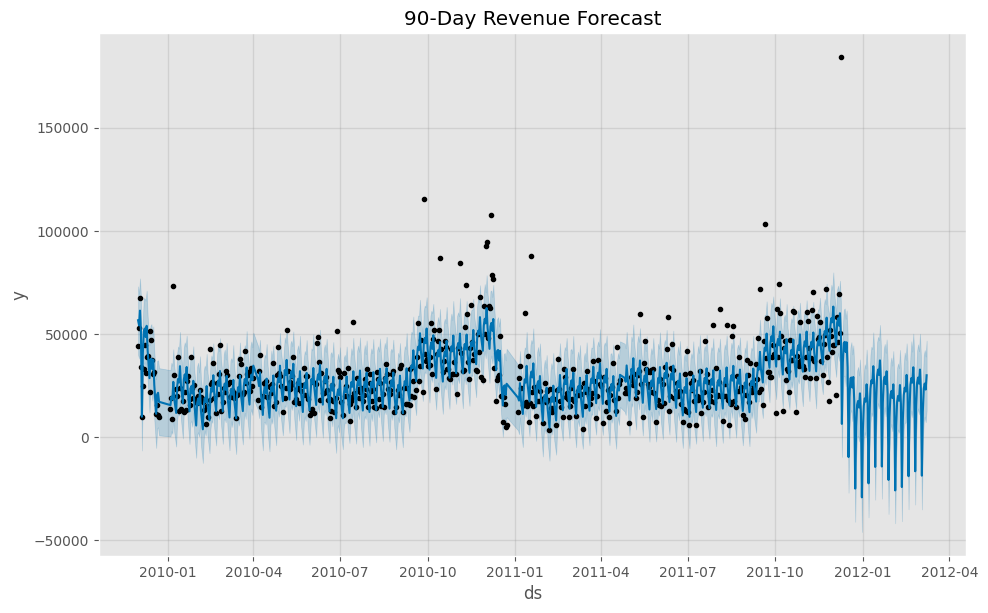

In [16]:
fig = model.plot(forecast)

plt.title("90-Day Revenue Forecast")

plt.show()

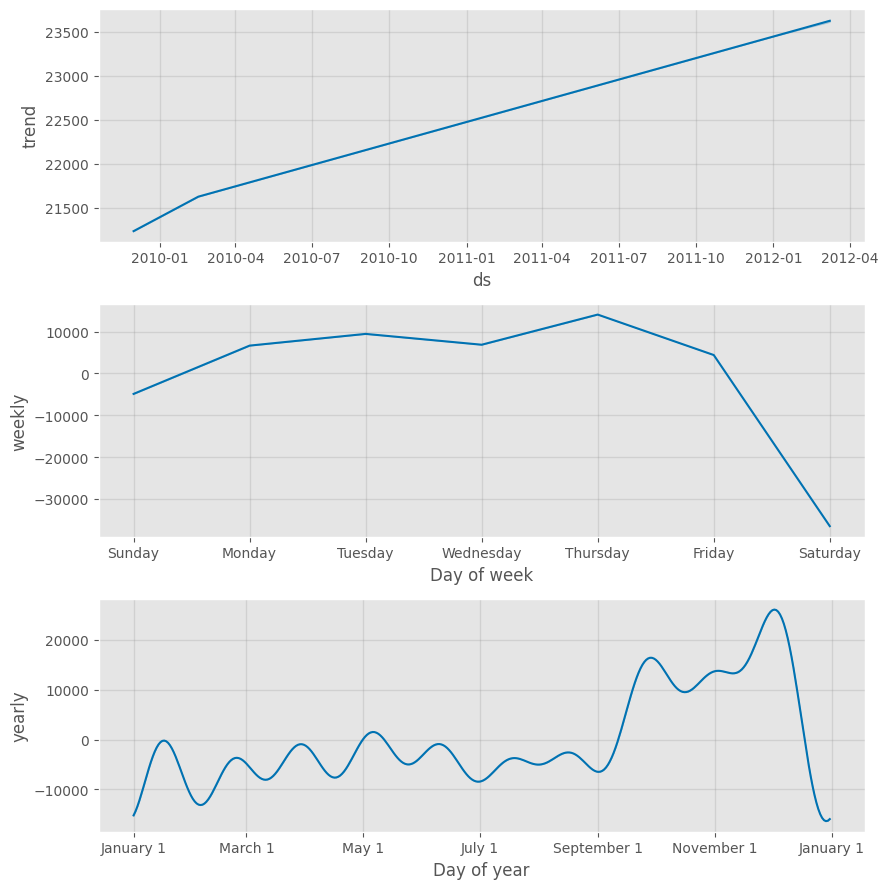

In [17]:
fig2 = model.plot_components(
    forecast
)

plt.show()

In [18]:
future_forecast = forecast[
    forecast['ds'] > daily_sales['ds'].max()
]

future_forecast.to_csv(
    "revenue_forecast.csv",
    index=False
)

print("Forecast saved successfully")

Forecast saved successfully


In [19]:
future_forecast[
    ['ds','yhat']
].head(10)

,ds,yhat
604,2011-12-10,6383.074758
605,2011-12-11,36114.790227
606,2011-12-12,45590.347846
607,2011-12-13,46158.599983
608,2011-12-14,41210.747323
609,2011-12-15,45953.461180
610,2011-12-16,33762.661908
611,2011-12-17,-9684.758287
612,2011-12-18,19388.267231
613,2011-12-19,28451.061818


Revenue Forecasting Insights
Prophet was used to forecast retail revenue for the next 90 days.
Historical daily revenue data was aggregated from transaction records.
The model identified long-term trends and weekly seasonal patterns.
Revenue is expected to remain stable/grow gradually over the forecast horizon.
Weekly fluctuations indicate varying customer purchasing behavior across different days.
Forecast confidence intervals provide a range of expected revenue values.


In [20]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].to_csv(
    "data/forecast.csv",
    index=False
)

In [21]:
daily_sales.to_csv(
    "data/daily_sales.csv",
    index=False
)

In [22]:
daily_sales.head()

,ds,y
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05
